
[基本資訊]
總列數: 194337 ；年份範圍: 2009 - 2025
Y=1 比例: 0.047

[2.1 變數表（前幾列）]
    Acronym              Description              Type  Source
0         Y  t→t+400 天內是否退市（Form 25）            binary  外部事件貼標
1       ROA                    NI/AT        continuous      衍生
2       LEV    (DLC+DLTT)/AT 或 LT/AT        continuous      衍生
3      SIZE                   ln(AT)        continuous      衍生
4       ICR                EBIT/XINT        continuous      衍生
5      SIC2                    兩位數產業       categorical   由 SIC
6     FYEAR                     會計年度  categorical/time      原始
7  DATADATE                     財報日期              date      原始

[2.2 缺值比例（Top 15）]
ICR      0.513716
ebit     0.348400
ROA      0.348390
ni       0.348369
sale     0.348354
xint     0.344345
dlc      0.264391
dltt     0.261052
lt       0.260187
LEV      0.260182
SIZE     0.259246
at       0.259246
fyear    0.000000
gvkey    0.000000
Y        0.000000
Name: missing_rate, dtype: float64

[2.2 缺值位置（前 30 列示意）]
    gvkey  fyear 

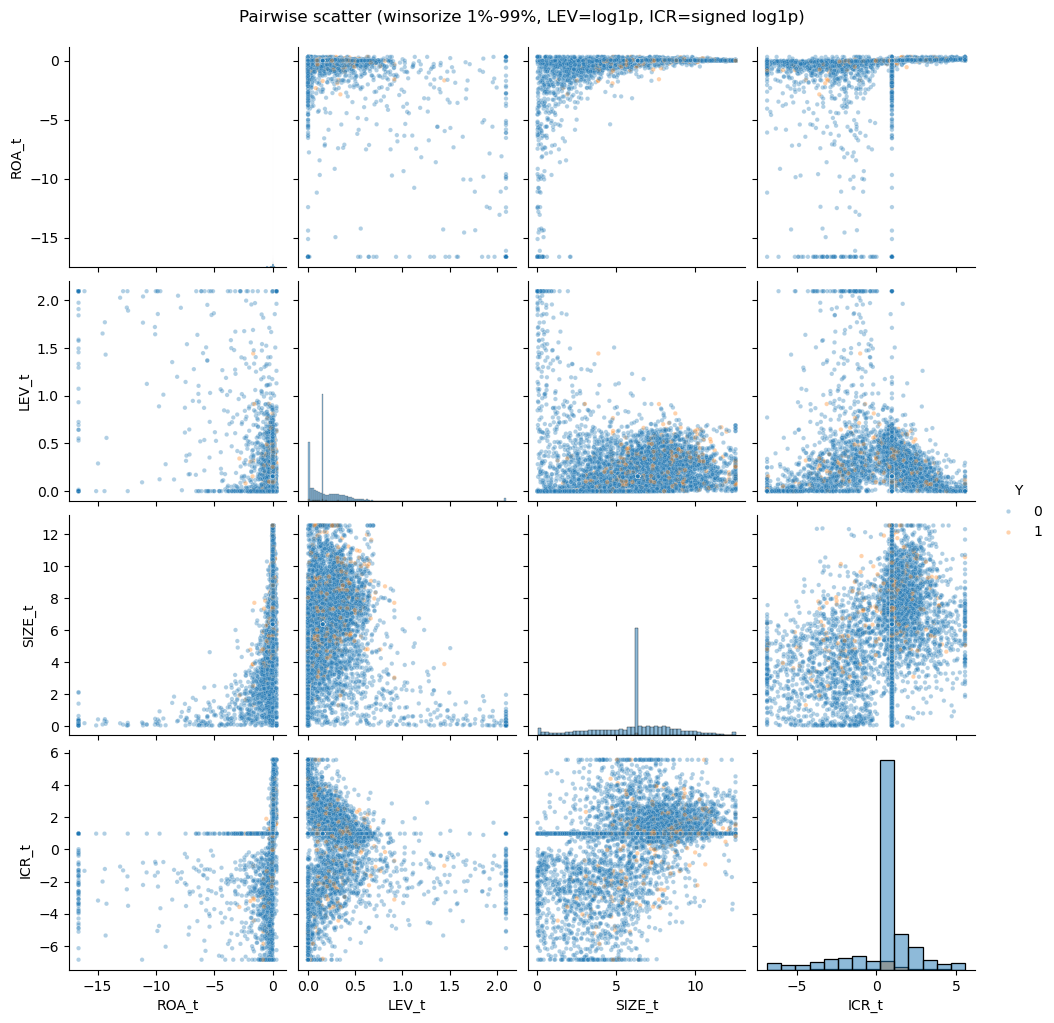


[繪圖] 相關性熱圖（winsorize/轉換後）


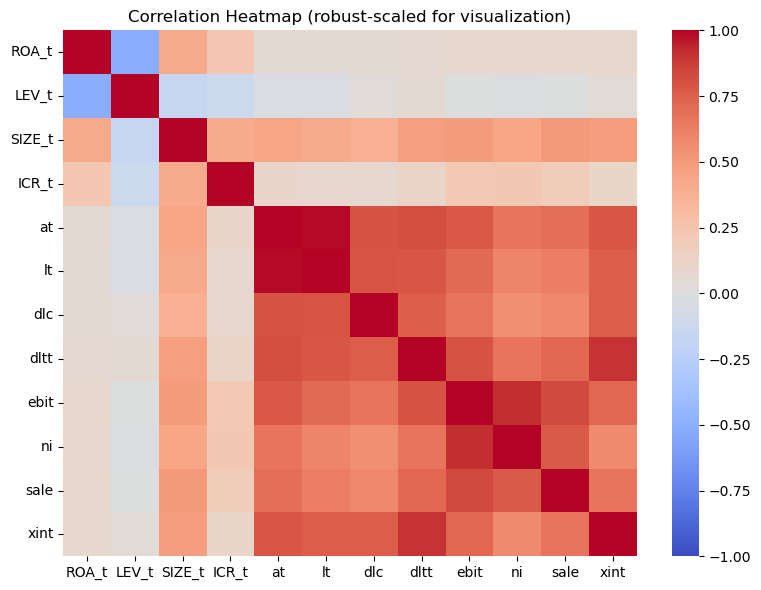


>>> EDA 完成


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 路徑 ---
CSV = r"C:\Users\User-NB\OneDrive\Desktop\ML\Fundamentals Annual_withY.csv"

# --- 顯示設定（讓表格易讀） ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
np.set_printoptions(edgeitems=3, linewidth=120, suppress=True)

# ---------- 0) 讀檔與基本欄位 ----------
df = pd.read_csv(CSV)
df.columns = [c.lower() for c in df.columns]
df["datadate"] = pd.to_datetime(df["datadate"], errors="coerce")
df["fyear"]    = pd.to_numeric(df["fyear"], errors="coerce").astype("Int64")
df["sic"]      = pd.to_numeric(df["sic"], errors="coerce")
df["sic2"]     = (df["sic"]//100).astype("Int64")
df["Y"]        = pd.to_numeric(df["y"] if "y" in df.columns else df["delisted_next_year"]).fillna(0).astype(int)

eps=1e-9
df["ROA"]  = df["ni"]/(df["at"]+eps)
df["LEV"]  = np.where(df[["dlc","dltt"]].notna().all(axis=1),
                      (df["dlc"].fillna(0)+df["dltt"].fillna(0))/(df["at"]+eps),
                      df["lt"]/(df["at"]+eps))
df["SIZE"] = np.log(df["at"]+1.0)
df["ICR"]  = df["ebit"]/df["xint"].replace(0, np.nan)

cont_cols = ["ROA","LEV","SIZE","ICR","at","lt","dlc","dltt","ebit","ni","sale","xint"]
cat_cols  = ["sic2","fyear"]

print("\n[基本資訊]")
print("總列數:", len(df), "；年份範圍:", int(df["fyear"].min()), "-", int(df["fyear"].max()))
print("Y=1 比例:", df["Y"].mean().round(4))

# ---------- 1) 2.1 變數表（螢幕印出） ----------
variables_21 = pd.DataFrame([
    ("Y","t→t+400 天內是否退市（Form 25）","binary","外部事件貼標"),
    ("ROA","NI/AT","continuous","衍生"),
    ("LEV","(DLC+DLTT)/AT 或 LT/AT","continuous","衍生"),
    ("SIZE","ln(AT)","continuous","衍生"),
    ("ICR","EBIT/XINT","continuous","衍生"),
    ("SIC2","兩位數產業","categorical","由 SIC"),
    ("FYEAR","會計年度","categorical/time","原始"),
    ("DATADATE","財報日期","date","原始"),
], columns=["Acronym","Description","Type","Source"])
print("\n[2.1 變數表（前幾列）]")
print(variables_21)

# ---------- 2) 2.2 缺值：比例＋位置（印出摘要 & 頭尾） ----------
check_cols = ["Y"]+cont_cols+cat_cols+["gvkey","datadate"]
miss_rate = df[check_cols].isna().mean().sort_values(ascending=False).rename("missing_rate")
print("\n[2.2 缺值比例（Top 15）]")
print(miss_rate.head(15))

# 缺值位置（只印前 30 列；你可調整顯示的筆數）
miss_locs=[]
for c in check_cols:
    idx=df.index[df[c].isna()].tolist()
    for i in idx[:1000]:  # 防爆列；想看更多改上限
        miss_locs.append({"gvkey":df.loc[i,"gvkey"],"fyear":df.loc[i,"fyear"],
                          "datadate":df.loc[i,"datadate"],"variable":c})
miss_locs_df = pd.DataFrame(miss_locs)
print("\n[2.2 缺值位置（前 30 列示意）]")
print(miss_locs_df.head(30))

# 缺值指示（>5%）
df_miss = df.copy()
high_miss_cols = miss_rate[miss_rate>0.05].index.tolist()
for c in high_miss_cols:
    if c in df_miss.columns:
        df_miss[f"{c}_miss"] = df_miss[c].isna().astype(int)
if high_miss_cols:
    print("\n[2.2 已加入缺值指示欄（>5%）]")
    print(high_miss_cols)
else:
    print("\n[2.2 無欄位缺值 >5%，無新增缺值指示]")

# ---------- 3) 2.2 極端值（只印摘要 + 各變數極端筆數） ----------
def iqr_bounds(s):
    q1,q3=s.quantile(0.25),s.quantile(0.75)
    return q1-1.5*(q3-q1), q3+1.5*(q3-q1)

rep=[]
for c in cont_cols:
    s=df[c].dropna()
    if s.empty: continue
    p01,p99=s.quantile(0.01),s.quantile(0.99)
    lo,hi=iqr_bounds(s)
    n_low=(df[c]<p01).sum(); n_high=(df[c]>p99).sum()
    rep.append({"var":c,"p01":p01,"p99":p99,"iqr_low":lo,"iqr_high":hi,"n_low":n_low,"n_high":n_high})
print("\n[2.2 極端值摘要（1%/99% & IQR；不刪除）]")
print(pd.DataFrame(rep).set_index("var").round(4))

# ---------- 4) 2.2 類別頻率 & 稀有類別建議 & Y 不平衡 ----------
sic_tab = df["sic2"].value_counts(dropna=False).rename_axis("SIC2").to_frame("count")
sic_tab["prop"]= (sic_tab["count"]/sic_tab["count"].sum()).round(4)
print("\n[2.2 產業別頻率（前 20）]")
print(sic_tab.head(20))

RARE_CUTOFF=30
rare = sic_tab[sic_tab["count"]<RARE_CUTOFF].copy()
rare["suggest_merge_to"]="Other"
print(f"\n[2.2 稀有類別（樣本 < {RARE_CUTOFF}）建議合併為 Other，顯示前 10]")
print(rare.head(10))

y_tab = df["Y"].value_counts().rename_axis("Y").to_frame("count")
y_tab["prop"]= (y_tab["count"]/y_tab["count"].sum()).round(4)
print("\n[2.2 Y 分布（不平衡檢查）]")
print(y_tab)

# ---------- 5) 2.2 連續變數摘要（含 skew/kurtosis & 轉換建議） ----------
from scipy.stats import skew, kurtosis
rows=[]
for c in cont_cols:
    s=df[c].dropna()
    if s.size==0:
        rows.append({"var":c,"n":0,"mean":np.nan,"sd":np.nan,"min":np.nan,"max":np.nan,
                     "skewness":np.nan,"kurtosis":np.nan,"transform_hint":""})
        continue
    sk=skew(s) if s.size>2 else np.nan
    kt=kurtosis(s,fisher=True) if s.size>3 else np.nan
    hint=""
    if abs(sk)>1:
        if c in ["LEV","SIZE"] or s.min()>=0: hint="log1p"
        elif c in ["ICR"]: hint="signed_log1p"
        else: hint="consider_transform"
    rows.append({"var":c,"n":int(s.size),"mean":float(s.mean()),"sd":float(s.std(ddof=1)),
                 "min":float(s.min()),"max":float(s.max()),
                 "skewness":float(sk) if sk==sk else np.nan,
                 "kurtosis":float(kt) if kt==kt else np.nan,
                 "transform_hint":hint})
print("\n[2.2 連續變數摘要（含轉換建議）]")
print(pd.DataFrame(rows).set_index("var").round(4))

# ---------- 6) Pairwise 散點圖（穩健版：winsorize + 轉換，只為視覺化） ----------
from sklearn.model_selection import StratifiedShuffleSplit

# 只為畫圖準備一份拷貝（不影響前面 EDA 統計）
viz = df.copy()

# (a) 先補最少量缺值（避免因 dropna 把資料丟光）
for col in ["ROA", "LEV", "SIZE", "ICR"]:
    med = viz[col].median(skipna=True)
    viz[col] = viz[col].fillna(med)

# (b) winsorize 1%~99%（避免少數極端值把圖撐爆）
def winsorize(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi), lo, hi

clip_info = {}
for col in ["ROA","LEV","SIZE","ICR"]:
    s0 = viz[col]
    s1, lo, hi = winsorize(s0, 0.01)
    clip_info[col] = {"p01": lo, "p99": hi,
                      "n_low": int((s0 < lo).sum()),
                      "n_high": int((s0 > hi).sum())}
    viz[col] = s1

# (c) 合理轉換：LEV 非負 → log1p；ICR 可正可負 → 有號 log；SIZE 已經是 ln(AT)
def sign_log1p(x): 
    return np.sign(x) * np.log1p(np.abs(x))

viz["ROA_t"]  = viz["ROA"]                 # 已 winsorize，維持原尺度
viz["LEV_t"]  = np.log1p(viz["LEV"].clip(lower=0))
viz["SIZE_t"] = viz["SIZE"]                # ln(AT)
viz["ICR_t"]  = sign_log1p(viz["ICR"])

print("\n[可視化 winsorize 摘要（1%/99% 截斷量）]")
print(pd.DataFrame(clip_info).T.round(4))

# (d) 採樣最多 8,000 列避免繪圖太慢
use = viz[["Y","ROA_t","LEV_t","SIZE_t","ICR_t"]].copy()
if len(use) > 8000:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=8000, random_state=42)
    _, idx = next(sss.split(use[["ROA_t","LEV_t","SIZE_t","ICR_t"]], use["Y"]))
    use = use.iloc[idx].copy()

# (e) 畫 pairplot（若 seaborn 失敗，退而畫幾張代表散點）
try:
    import seaborn as sns
    print("\n[繪圖] Pairwise scatter after winsorize & transforms")
    g = sns.pairplot(
        use, vars=["ROA_t","LEV_t","SIZE_t","ICR_t"], hue="Y",
        diag_kind="hist", plot_kws=dict(alpha=0.35, s=10)
    )
    g.fig.suptitle("Pairwise scatter (winsorize 1%-99%, LEV=log1p, ICR=signed log1p)", y=1.02)
    plt.show()
except Exception as e:
    print("\n[繪圖] seaborn pairplot 失敗：", repr(e))
    print("[繪圖] 改畫幾張代表散點 (matplotlib)")
    for x, y in [("ROA_t","LEV_t"), ("SIZE_t","ROA_t"), ("LEV_t","ICR_t")]:
        plt.figure(); plt.scatter(use[x], use[y], c=use["Y"], alpha=0.3, s=10)
        plt.xlabel(x); plt.ylabel(y); plt.title(f"{x} vs {y}")
        plt.show()

# ---------- 7) 相關性熱圖（用 winsorize+轉換後的數值，畫面更可讀） ----------
num_viz = viz[["ROA_t","LEV_t","SIZE_t","ICR_t","at","lt","dlc","dltt","ebit","ni","sale","xint"]].copy()
# 對非衍生原始欄位，為避免極端值影響熱圖也做一次簡易 winsorize
for col in ["at","lt","dlc","dltt","ebit","ni","sale","xint"]:
    if col in num_viz.columns:
        s = num_viz[col]
        num_viz[col] = s.clip(s.quantile(0.01), s.quantile(0.99))

corr = num_viz.corr()
try:
    import seaborn as sns
    print("\n[繪圖] 相關性熱圖（winsorize/轉換後）")
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap (robust-scaled for visualization)")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("\n[繪圖] 熱圖 seaborn 失敗：", repr(e))
    plt.figure(figsize=(8,6)); plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm"); plt.colorbar()
    plt.title("Correlation Heatmap (robust-scaled for visualization)")
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.tight_layout(); plt.show()

print("\n>>> EDA 完成")


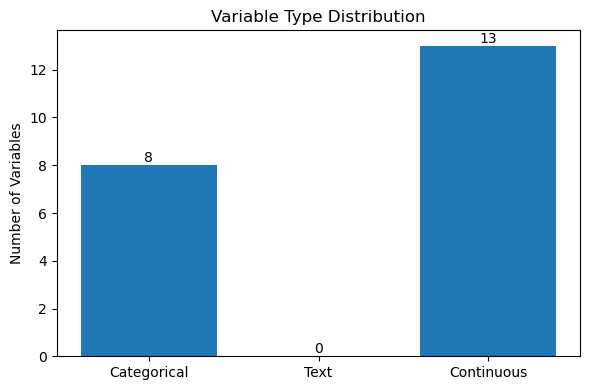

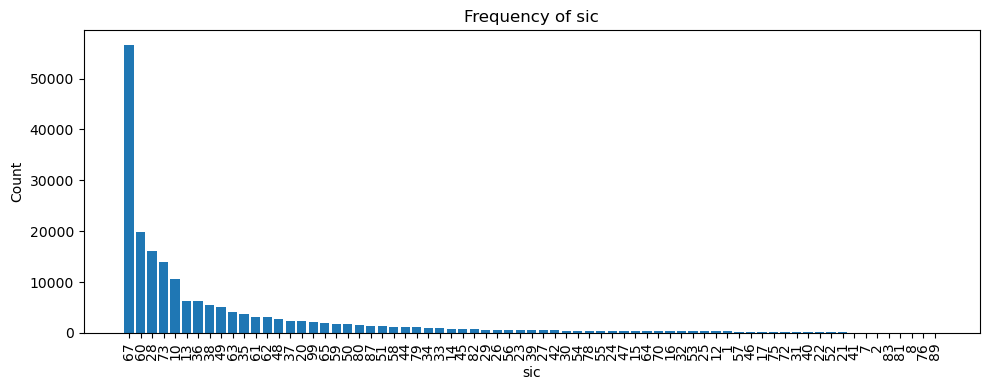

# companies: 23033
# features:  21
Class imbalance (Y=1 ratio): 0.0470


In [9]:
# ---------- 8) PPT 圖：變數型態分佈 & SIC 頻率（僅顯示，不存檔） ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def classify_col(s: pd.Series) -> str:
    """粗分欄位型態供視覺化：Continuous / Categorical / Text"""
    n = len(s)
    nunique = s.nunique(dropna=True)

    if pd.api.types.is_numeric_dtype(s):
        # 唯一值很少 → 視為類別，否則連續
        if nunique <= 20 or (nunique / max(n, 1)) <= 0.05:
            return "Categorical"
        return "Continuous"

    if pd.api.types.is_string_dtype(s):
        avg_len = s.dropna().astype(str).str.len().mean() or 0
        if (nunique / max(n, 1)) >= 0.2 and avg_len >= 4:
            return "Text"
        return "Categorical"

    return "Text"

# 可選：排除不是特徵的欄位（ID、標籤、日期等）
not_features = {"gvkey","conm","datadate","y","Y","delisted_next_year"}
cols_for_audit = [c for c in df.columns if c not in not_features]

# (A) 變數型態分佈
type_map = {c: classify_col(df[c]) for c in cols_for_audit if c in df.columns}
type_counts = pd.Series(type_map).value_counts()\
    .reindex(["Categorical","Text","Continuous"]).fillna(0).astype(int)

plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Variable Type Distribution")
plt.ylabel("Number of Variables")
for i, v in enumerate(type_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

# (B) SIC 頻率（兩位數 SIC2）
sic_counts = df["sic2"].dropna().astype(int).value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,4))
plt.bar(sic_counts.index.astype(str), sic_counts.values)
plt.title("Frequency of sic")
plt.xlabel("sic")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# (C) Slide 用數字：公司數、特徵數、類別不平衡
n_companies = df["gvkey"].nunique() if "gvkey" in df.columns else np.nan
n_features  = int(type_counts.sum())
y_ratio_1   = df["Y"].mean() if "Y" in df.columns else np.nan
print(f"# companies: {n_companies}")
print(f"# features:  {n_features}")
print(f"Class imbalance (Y=1 ratio): {y_ratio_1:.4f}")


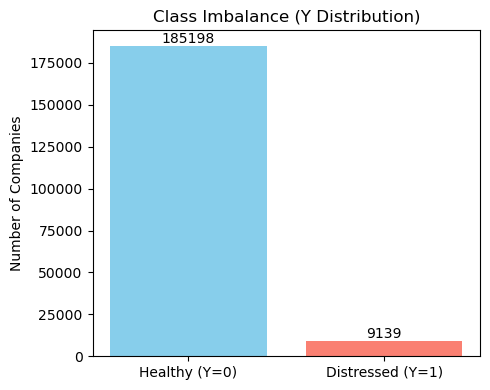

Y=1 ratio: 0.0470


In [10]:
# ---------- 8) Y 分布（class imbalance） ----------
import matplotlib.pyplot as plt

y_counts = df["Y"].value_counts().sort_index()
y_labels = ["Healthy (Y=0)", "Distressed (Y=1)"]

plt.figure(figsize=(5,4))
plt.bar(y_labels, y_counts.values, color=["skyblue", "salmon"])
plt.title("Class Imbalance (Y Distribution)")
plt.ylabel("Number of Companies")
for i, v in enumerate(y_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Y=1 ratio: {df['Y'].mean():.4f}")


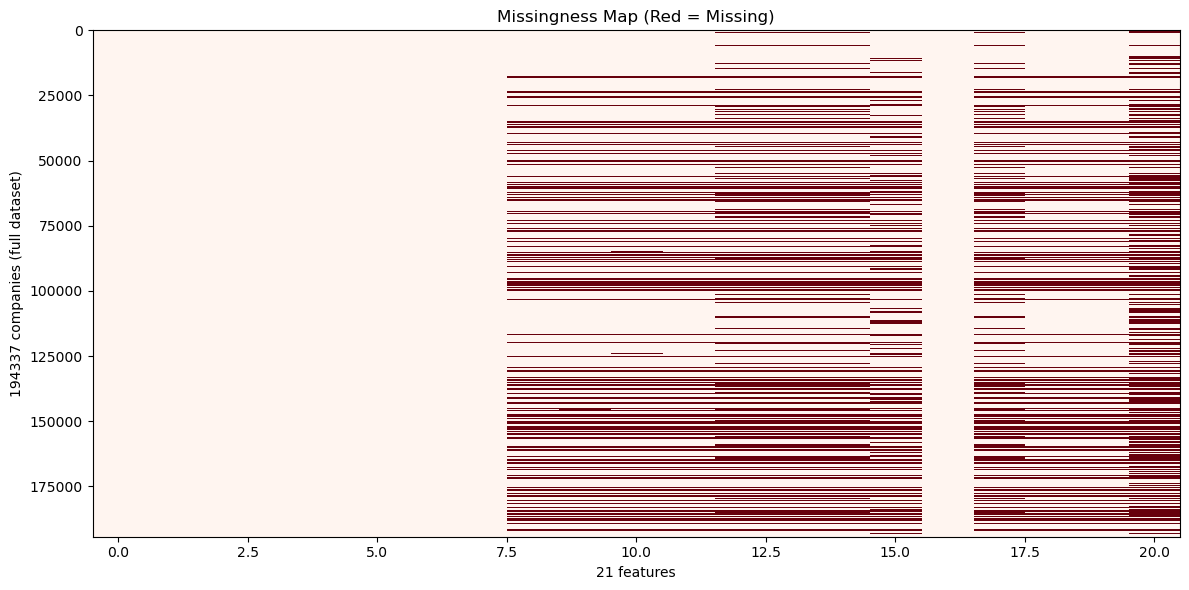


[Top 10 missing-rate columns]
ICR     0.513716
ebit    0.348400
ROA     0.348390
ni      0.348369
sale    0.348354
xint    0.344345
dlc     0.264391
dltt    0.261052
lt      0.260187
LEV     0.260182
dtype: float64

Average missing rate across all features: 18.17%


In [15]:
# ---------- 9) 全公司 × 全欄位缺值可視化（Missingness Map, Full Data） ----------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 不抽樣，使用全部公司
df_sample = df.copy()

# 排除無意義欄位（避免軸太長）
exclude_cols = ["gvkey", "datadate", "fyear", "Y", "y", "delisted_next_year"]
use_cols = [c for c in df.columns if c not in exclude_cols]

# 建立缺值矩陣：1 = missing, 0 = present
missing_matrix = df_sample[use_cols].isna().astype(int)

plt.figure(figsize=(12,6))
plt.imshow(missing_matrix, aspect='auto', cmap='Reds', interpolation='nearest')
plt.title("Missingness Map (Red = Missing)")
plt.xlabel(f"{len(use_cols)} features")
plt.ylabel(f"{len(df_sample)} companies (full dataset)")
plt.tight_layout()
plt.show()

# 額外輸出缺值比例摘要（前10名 + 平均）
miss_rate = df[use_cols].isna().mean().sort_values(ascending=False)
print("\n[Top 10 missing-rate columns]")
print(miss_rate.head(10))
print(f"\nAverage missing rate across all features: {miss_rate.mean():.2%}")


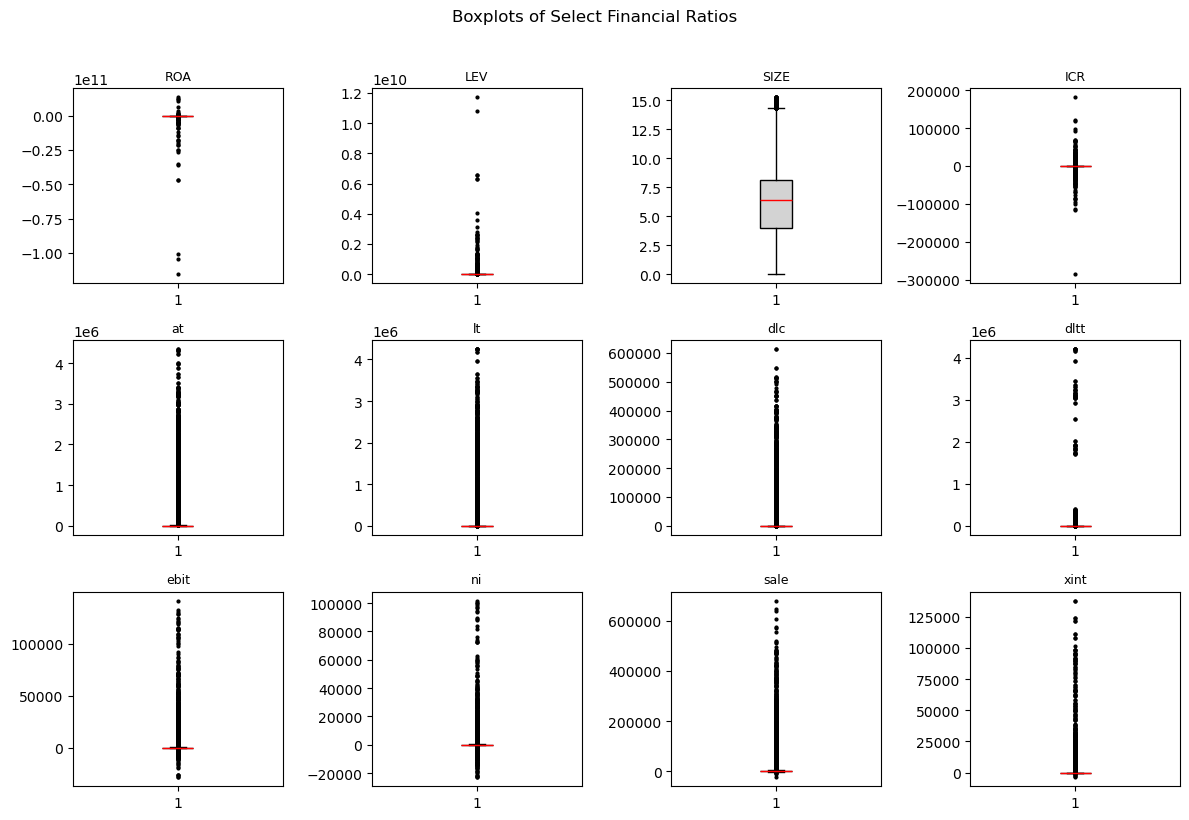


[Summary of Boxplot Features]
   Variable         Mean   Median  Outliers  Skewness   Kurtosis
0       ROA -6869530.057    0.005     19738  -140.972  23346.638
1       LEV  1144596.707    0.169      7034   113.355  16453.892
2      SIZE        6.116    6.370       412    -0.080     -0.350
3       ICR      -54.033    1.667     23307   -19.698   4470.595
4        at    20730.173  582.780     21943    14.346    247.710
5        lt    17758.455  315.032     22192    14.882    266.244
6       dlc     1433.991    4.407     25902    19.336    449.168
7      dltt     3902.347   34.153     23808    49.552   2719.406
8      ebit      528.022    6.859     22391    18.274    499.062
9        ni      271.610    1.172     27986    20.721    746.887
10     sale     3703.265  141.592     19603    13.857    283.161
11     xint      211.922    4.701     19058    31.932   1255.554

[EDA Conclusions]
The selected financial ratios exhibit heavy-tailed and skewed distributions, indicating the presence of e

In [17]:
# ---------- 10) Boxplots of select features + 結論摘要 ----------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 選擇代表性財務變數（可自行增減）
select_cols = ["ROA", "LEV", "SIZE", "ICR", "at", "lt", "dlc", "dltt", "ebit", "ni", "sale", "xint"]

# --- 畫圖 ---
n = len(select_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(12, 8))
for i, c in enumerate(select_cols, 1):
    plt.subplot(nrows, ncols, i)
    plt.boxplot(df[c].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="lightgray", color="black"),
                medianprops=dict(color="red"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(markerfacecolor="black", marker='o', markersize=2, linestyle='none'))
    plt.title(c, fontsize=9)
plt.suptitle("Boxplots of Select Financial Ratios", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# --- 自動生成統計摘要與結論 ---
summary = []
for c in select_cols:
    s = df[c].dropna()
    if len(s) < 10:  # 資料太少略過
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).sum()
    skewness = s.skew()
    kurt = s.kurtosis()
    summary.append({
        "Variable": c,
        "Mean": s.mean(),
        "Median": s.median(),
        "Outliers": outliers,
        "Skewness": skewness,
        "Kurtosis": kurt
    })

summary_df = pd.DataFrame(summary)
print("\n[Summary of Boxplot Features]")
print(summary_df.round(3))

# --- 根據分布自動生成結論文字 ---
text_summary = []
for _, row in summary_df.iterrows():
    c = row["Variable"]
    sk = row["Skewness"]
    out = row["Outliers"]
    if sk > 1:
        shape = "highly right-skewed"
    elif sk < -1:
        shape = "highly left-skewed"
    else:
        shape = "approximately symmetric"
    text_summary.append(f"- {c}: {shape}, with {int(out)} outliers detected.")

print("\n[EDA Conclusions]")
print("The selected financial ratios exhibit heavy-tailed and skewed distributions, "
      "indicating the presence of extreme values across firms. "
      "Winsorization or log transformation is recommended for normalization.\n")
print("\n".join(text_summary))


In [18]:
# ---------- 11) Description summary for selected numerical features ----------
import pandas as pd
import numpy as np

# 選取要展示的變數（你可依照資料實際變數改）
num_cols = ["ROA", "LEV", "SIZE", "ICR", "at", "lt", "dlc", "dltt", "ebit", "ni", "sale", "xint"]

# 計算描述統計
desc = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc["skewness"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()

# 數值四捨五入
desc_rounded = desc.round(2)

print("\n[Descriptive Summary of Selected Numerical Features]")
print(desc_rounded)

# --- 自動生成簡短結論 ---
high_skew = desc_rounded[desc_rounded["skewness"].abs() > 1].index.tolist()
high_kurt = desc_rounded[desc_rounded["kurtosis"] > 10].index.tolist()

print("\n[EDA Conclusions]")
if high_skew:
    print(f"• Most variables are highly skewed (|skew|>1), especially: {', '.join(high_skew[:6])}...")
if high_kurt:
    print(f"• Several variables exhibit extreme kurtosis (>10), indicating heavy tails, such as: {', '.join(high_kurt[:6])}.")
print("• Log or winsorized transformations are recommended before model estimation.")



[Descriptive Summary of Selected Numerical Features]
         count        mean           std           min    25%     50%      75%           max  skewness  kurtosis
ROA   126632.0 -6869530.06  6.125031e+08 -1.154960e+11  -0.19    0.00     0.05  1.350200e+10   -140.97  23346.64
LEV   143774.0  1144596.71  6.431927e+07  0.000000e+00   0.03    0.17     0.41  1.172300e+10    113.36  16453.89
SIZE  143956.0        6.12  2.960000e+00  0.000000e+00   4.02    6.37     8.14  1.529000e+01     -0.08     -0.35
ICR    94503.0      -54.03  2.173370e+03 -2.855470e+05  -4.85    1.67     6.85  1.817916e+05    -19.70   4470.59
at    143956.0    20730.17  1.526165e+05  0.000000e+00  54.88  582.78  3439.39  4.349731e+06     14.35    247.71
lt    143773.0    17758.46  1.431946e+05 -1.000000e-01  17.28  315.03  2244.00  4.255074e+06     14.88    266.24
dlc   142956.0     1433.99  1.560927e+04 -5.600000e+01   0.00    4.41    62.90  6.142374e+05     19.34    449.17
dltt  143605.0     3902.35  6.283327e+04 -